# Tugas 1 – Data Preprocessing Mahasiswa

Tahapan: Load Dataset, EDA, Missing Values, Normalisasi Tanggal, Label Encoding, Split Data, dan Visualisasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

file_path = "dataset_tugas1_preprocessing.csv"
df = pd.read_csv(file_path)
print("Ukuran dataset:", df.shape)
display(df.head())

Ukuran dataset: (99, 8)


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0


## Tahap 2: Eksplorasi Awal (EDA)

In [2]:
df.info()
print("\nJumlah nilai hilang per kolom:")
display(df.isna().sum().to_frame("Jumlah Missing"))
print("\nStatistik deskriptif:")
display(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB

Jumlah nilai hilang per kolom:


,Jumlah Missing
ID,0
Nama,0
Jenis_Kelamin,0
Prodi,0
Status,0
Nilai_Akhir,29
Tanggal_Ujian,0
Umur,9



Statistik deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,99,99,MH001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nama,99,10,Eka,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Jenis_Kelamin,99,2,Laki-laki,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Prodi,99,4,Teknik Komputer,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,99,4,Cuti,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nilai_Akhir,70,5,C,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tanggal_Ujian,99,97,2020/03/31,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Umur,90.0,NaN,NaN,NaN,23.366667,3.763963,18.0,20.0,23.0,26.0,30.0


## Tahap 3: Menangani Missing Values

`Umur` diimputasi dengan median karena numerik. `Nilai_Akhir` diimputasi dengan modus karena kategorikal.

In [3]:
df_clean = df.copy()
median_umur = df_clean["Umur"].median()
modus_nilai = df_clean["Nilai_Akhir"].mode()[0]
df_clean["Umur"] = df_clean["Umur"].fillna(median_umur)
df_clean["Nilai_Akhir"] = df_clean["Nilai_Akhir"].fillna(modus_nilai)
print("Median Umur:", median_umur)
print("Modus Nilai_Akhir:", modus_nilai)
display(df_clean.isna().sum().to_frame("Missing Setelah Imputasi"))

Median Umur: 23.0
Modus Nilai_Akhir: C


,Missing Setelah Imputasi
ID,0
Nama,0
Jenis_Kelamin,0
Prodi,0
Status,0
Nilai_Akhir,0
Tanggal_Ujian,0
Umur,0


## Tahap 4: Normalisasi Format Tanggal

In [4]:
df_clean["Tanggal_Ujian"] = pd.to_datetime(
    df_clean["Tanggal_Ujian"], errors="coerce", format="mixed"
)
print("Tanggal gagal dikonversi:", df_clean["Tanggal_Ujian"].isna().sum())
print("Tipe data:", df_clean["Tanggal_Ujian"].dtype)
display(df_clean[["Tanggal_Ujian"]].head())

Tanggal gagal dikonversi: 0
Tipe data: datetime64[ns]


,Tanggal_Ujian
0,2020-04-13
1,2020-12-11
2,2021-11-21
3,2021-08-19
4,2020-01-05


## Tahap 5: Label Encoding

In [5]:
categorical_cols = ["Nama", "Jenis_Kelamin", "Prodi", "Status", "Nilai_Akhir"]
label_encoders = {}
encoding_mapping = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    encoding_mapping[col] = dict(zip(le.classes_, le.transform(le.classes_)))

for col, mapping in encoding_mapping.items():
    print(f"{col}: {mapping}")

display(df_clean.head())

Nama: {'Adi': np.int64(0), 'Budi': np.int64(1), 'Citra': np.int64(2), 'Dina': np.int64(3), 'Eka': np.int64(4), 'Farhan': np.int64(5), 'Gita': np.int64(6), 'Hana': np.int64(7), 'Iwan': np.int64(8), 'Joko': np.int64(9)}
Jenis_Kelamin: {'Laki-laki': np.int64(0), 'Perempuan': np.int64(1)}
Prodi: {'Data Science': np.int64(0), 'Informatika': np.int64(1), 'Sistem Informasi': np.int64(2), 'Teknik Komputer': np.int64(3)}
Status: {'Aktif': np.int64(0), 'Cuti': np.int64(1), 'DO': np.int64(2), 'Lulus': np.int64(3)}
Nilai_Akhir: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4)}


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,8,0,3,0,2,2020-04-13,23.0
1,MH002,4,1,3,3,4,2020-12-11,28.0
2,MH003,8,0,3,0,2,2021-11-21,23.0
3,MH004,4,1,3,0,3,2021-08-19,18.0
4,MH005,9,1,0,0,2,2020-01-05,26.0


## Tahap 6: Split Data 80%–20%

Karena soal tidak menetapkan target tertentu, pembagian dilakukan terhadap seluruh dataset hasil preprocessing.

In [6]:
df_model = df_clean.copy()
df_model["Tahun_Ujian"] = df_model["Tanggal_Ujian"].dt.year
df_model["Bulan_Ujian"] = df_model["Tanggal_Ujian"].dt.month
df_model["Hari_Ujian"] = df_model["Tanggal_Ujian"].dt.day
df_model = df_model.drop(columns=["Tanggal_Ujian"])

X_train, X_test = train_test_split(df_model, test_size=0.20, random_state=42)
print("Data latih:", X_train.shape)
print("Data uji:", X_test.shape)
display(X_train.head())

Data latih: (79, 10)
Data uji: (20, 10)


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Umur,Tahun_Ujian,Bulan_Ujian,Hari_Ujian
49,MH050,4,1,1,2,2,21.0,2021,10,1
70,MH071,5,0,1,2,2,19.0,2021,8,15
68,MH069,7,1,1,1,1,24.0,2022,1,21
15,MH016,4,0,2,3,4,19.0,2020,2,11
39,MH040,2,0,1,1,2,29.0,2022,3,21


## Tahap 7: Visualisasi

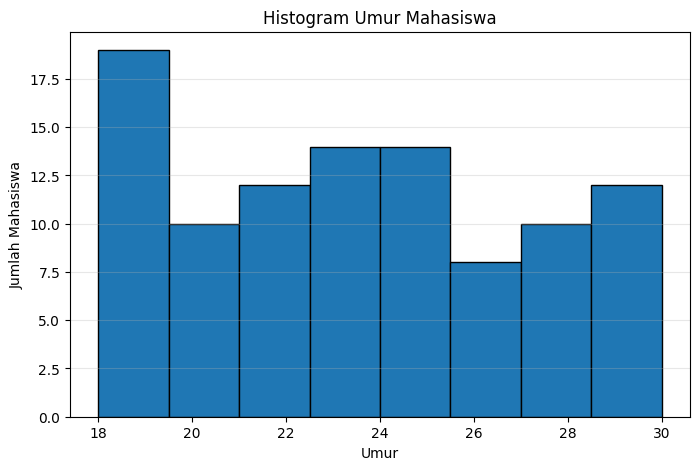

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df_clean["Umur"], bins=8, edgecolor="black")
plt.title("Histogram Umur Mahasiswa")
plt.xlabel("Umur")
plt.ylabel("Jumlah Mahasiswa")
plt.grid(axis="y", alpha=0.3)
plt.show()

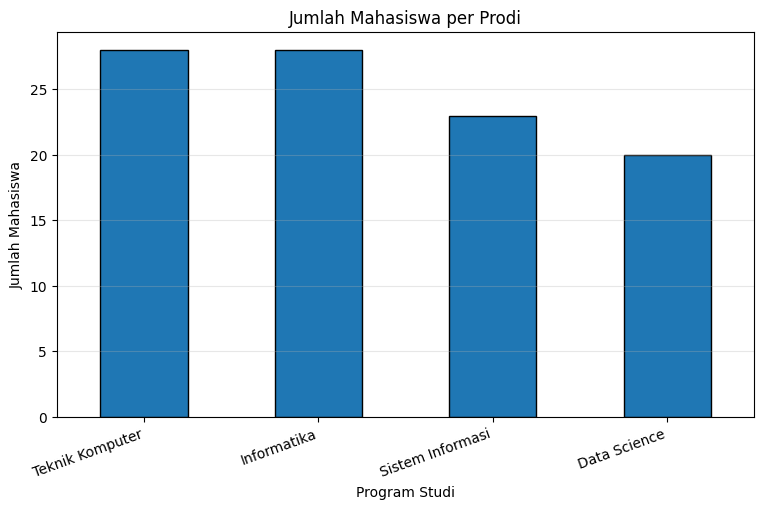

In [8]:
prodi_counts = df["Prodi"].value_counts()
plt.figure(figsize=(9,5))
prodi_counts.plot(kind="bar", edgecolor="black")
plt.title("Jumlah Mahasiswa per Prodi")
plt.xlabel("Program Studi")
plt.ylabel("Jumlah Mahasiswa")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Kesimpulan

Dataset telah dibersihkan, missing value ditangani, tanggal dinormalisasi, data kategorikal di-Label Encoding, dan data dibagi 80%–20%. Visualisasi umur dan jumlah mahasiswa per Prodi juga telah dibuat.